# Cross-Bracket Probability Arbitrage Backtest

## Strategy

Each Kalshi weather day has multiple price brackets per city. Exactly **one bracket settles YES**,
so the true probabilities across all brackets for a city-day **must sum to 1.0**.

When the market-implied sum deviates significantly from 1.0, at least one bracket is mispriced.
We identify the single most mispriced qualifying bracket and trade it.

### Key filter: 25–75 cent range
Brackets with `yes_price < 0.25` or `yes_price > 0.75` are **excluded from trading** and from
the probability-sum calculation. Extreme brackets have thin liquidity, wide spreads, and are
likely correctly priced by informed participants. Mid-probability brackets (25–75¢) are where
retail mispricing is most likely and liquidity is most adequate.

### Signal logic
- For each city-day at each snapshot time (10:00, 16:00, 22:00 UTC):
  - Get the last traded YES price for each bracket active that day
  - Compute `fair_prob_i = 1.0 − sum(all other brackets' last prices)`
  - For qualifying brackets (25–75¢): `mispricing = yes_price − fair_prob`
  - Positive mispricing → YES overpriced → **BUY NO**
  - Negative mispricing → YES underpriced → **BUY YES**
  - Trade only the single most mispriced qualifying bracket per city-day-snapshot
  - Deduplicate to one trade per city-day (earliest snapshot that fires)

### Train / Test split
Data is sorted by settlement date. **First 70% of dates = TRAIN**, **last 30% = TEST**.
Train uses fixed 10 contracts. Test uses half-Kelly sizing derived from train results.

In [1]:
# Cell 2: Imports & Config
import math
import re
import io
import contextlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from scipy import stats

# ── Data location ──────────────────────────────────────────────────────────────
DATA_DIR = Path(r"C:\Users\ethan\Downloads\Kalshitrading\LIVE\backtest_data")

CITIES = {
    "LAX": "KXHIGHLAX",
    "NY":  "KXHIGHNY",
    "CHI": "KXHIGHCHI",
    "MIA": "KXHIGHMIA",
    "DEN": "KXHIGHDEN",
}

# ── Signal parameters ──────────────────────────────────────────────────────────
SLIPPAGE            = 0.04    # added to entry price (dollars)
MISPRICING_THRESHOLD = 0.04   # minimum abs(mispricing) to trigger signal
YES_PRICE_MIN       = 0.25    # exclude brackets below this from trading AND sum
YES_PRICE_MAX       = 0.75    # exclude brackets above this from trading AND sum
SNAPSHOT_HOURS_UTC  = [10, 16, 22]   # UTC snapshot times per day

# ── Account / position sizing ──────────────────────────────────────────────────
STARTING_BALANCE  = 500.0
TRAIN_CONTRACTS   = 10
MIN_CONTRACTS     = 1
MAX_CONTRACTS     = 50
KELLY_FRACTION    = 0.5

# ── Train / Test split ─────────────────────────────────────────────────────────
TRAIN_FRACTION    = 0.70      # first 70% of unique dates → TRAIN

# ── Regex for parsing settlement date from ticker ─────────────────────────────
DATE_RE = re.compile(r"-(\d{2}[A-Z]{3}\d{2})-")

In [2]:
# Cell 3: Load Data
#
# Load trades and markets CSVs for all 5 cities.
# Timestamps parsed as UTC. Markets get a yes_won boolean column.

trades_dfs  = {}
markets_dfs = {}

for city, prefix in CITIES.items():
    trades_path  = DATA_DIR / f"{prefix}_trades.csv"
    markets_path = DATA_DIR / f"{prefix}_markets.csv"

    # ── Trades ──
    t = pd.read_csv(trades_path)
    t["created_time"] = pd.to_datetime(t["created_time"], utc=True)
    t["city"] = city
    trades_dfs[city] = t

    # ── Markets ──
    m = pd.read_csv(markets_path)
    m["close_time"] = pd.to_datetime(m["close_time"], utc=True, errors="coerce")
    m["yes_won"] = m["settlement_value"] >= 0.99
    m["city"] = city
    markets_dfs[city] = m

    print(f"{city:3s}  trades: {t.shape}   markets: {m.shape}")

print()
print("Trades columns :", trades_dfs["NY"].columns.tolist())
print("Markets columns:", markets_dfs["NY"].columns.tolist())

LAX  trades: (1381011, 9)   markets: (2598, 6)
NY   trades: (1894566, 9)   markets: (8452, 6)
CHI  trades: (1332526, 9)   markets: (8449, 6)
MIA  trades: (1046962, 9)   markets: (6220, 6)
DEN  trades: (874145, 9)   markets: (2874, 6)

Trades columns : ['trade_id', 'ticker', 'count_fp', 'yes_price_dollars', 'no_price_dollars', 'taker_side', 'created_time', 'ts', 'city']
Markets columns: ['ticker', 'result', 'settlement_value', 'close_time', 'yes_won', 'city']


In [3]:
# Cell 4: Build Snapshot Signals
#
# For each city, day, and snapshot hour (10/16/22 UTC):
#   1. Gather all brackets that traded on that city-day.
#   2. For each bracket, find the last trade at or before the snapshot timestamp.
#      If ANY bracket has no trade yet at this snapshot, skip this snapshot entirely.
#   3. Identify qualifying brackets: 0.25 <= yes_price <= 0.75.
#      Brackets outside this range are NOT traded but their prices ARE used
#      in the fair-value calculation for qualifying brackets.
#   4. If fewer than 2 qualifying brackets, skip.
#   5. Compute fair_prob_i = 1.0 - sum(last_price_j for j != i) for each bracket.
#      Clamp to [0.001, 0.999].
#   6. For qualifying brackets: mispricing = yes_price - fair_prob.
#   7. Take the single most mispriced qualifying bracket (largest abs mispricing).
#   8. If abs(mispricing) > MISPRICING_THRESHOLD, record the signal.
#   9. Deduplicate: keep only the earliest snapshot per city-day that fires.
#  10. Merge with settlement data.


def parse_market_date(date_str: str) -> pd.Timestamp | None:
    """Parse a ticker date string like '26MAR13' into a pandas Timestamp (date only)."""
    try:
        return pd.to_datetime(date_str, format="%y%b%d")
    except Exception:
        return None


def build_snapshot_signals() -> pd.DataFrame:
    """Build the full cross-bracket arb signal DataFrame across all cities.

    Returns
    -------
    DataFrame sorted by (market_date, city) with one row per signal, containing:
    ticker, city, market_date, snapshot_hour, yes_price, no_price_dollars,
    fair_prob, mispricing, side (BUY_NO / BUY_YES), settlement_value,
    yes_won, mispricing_value (alias for mispricing, for Cell 13).
    """
    all_signals = []

    for city, prefix in CITIES.items():
        trades  = trades_dfs[city].copy()
        markets = markets_dfs[city][["ticker", "settlement_value", "yes_won"]].copy()

        # ── Extract market_date from ticker ──────────────────────────────────────
        trades["date_str"]    = trades["ticker"].str.extract(DATE_RE)
        trades["market_date"] = trades["date_str"].apply(parse_market_date)
        trades = trades.dropna(subset=["market_date"])
        trades["market_date"] = trades["market_date"].dt.normalize()

        # Sort ascending so "last" means most recent before cutoff
        trades = trades.sort_values("created_time")

        city_signal_count = 0

        for mdate, day_trades in trades.groupby("market_date"):
            # All tickers (brackets) present on this city-day
            day_tickers = day_trades["ticker"].unique().tolist()
            if len(day_tickers) < 2:
                continue

            # Build a dict of {ticker: all trades on this day} for fast lookup
            ticker_day_map = {tk: grp for tk, grp in day_trades.groupby("ticker")}

            # Track whether we already fired a signal for this city-day
            fired_signal: dict | None = None

            for snap_hour in SNAPSHOT_HOURS_UTC:
                if fired_signal is not None:
                    # Already have a signal for this city-day; stop scanning snapshots
                    break

                # Build a snapshot: for each ticker, get the last trade
                # at or before snap_hour UTC on this date
                snap_cutoff = pd.Timestamp(mdate).replace(hour=snap_hour, tzinfo=None)
                snap_cutoff = pd.Timestamp(snap_cutoff, tz="UTC")

                snapshot: dict[str, dict] = {}
                all_have_price = True

                for tk in day_tickers:
                    tk_trades = ticker_day_map[tk]
                    before_snap = tk_trades[tk_trades["created_time"] <= snap_cutoff]
                    if before_snap.empty:
                        all_have_price = False
                        break
                    last_row = before_snap.iloc[-1]
                    snapshot[tk] = {
                        "yes_price": float(last_row["yes_price_dollars"]),
                        "no_price":  float(last_row["no_price_dollars"]),
                    }

                if not all_have_price:
                    # At least one bracket has no price yet at this snapshot — skip
                    continue

                # ── Identify qualifying brackets (25–75 range) ───────────────────
                qualifying = {
                    tk: v for tk, v in snapshot.items()
                    if YES_PRICE_MIN <= v["yes_price"] <= YES_PRICE_MAX
                }
                if len(qualifying) < 2:
                    continue

                # ── Compute fair_prob for each qualifying bracket ─────────────────
                # fair_prob_i = 1.0 - sum(all other brackets' last prices)
                # Uses ALL brackets (including non-qualifying) in the sum.
                total_all = sum(v["yes_price"] for v in snapshot.values())

                best_mispricing: float = 0.0
                best_rec: dict | None = None

                for tk, v in qualifying.items():
                    yes_p = v["yes_price"]
                    # Sum of all others = total_all - yes_p
                    sum_others = total_all - yes_p
                    fair_prob  = 1.0 - sum_others
                    fair_prob  = max(0.001, min(0.999, fair_prob))

                    mispricing = yes_p - fair_prob   # positive → YES overpriced → BUY NO

                    if abs(mispricing) > abs(best_mispricing):
                        best_mispricing = mispricing
                        best_rec = {
                            "ticker":         tk,
                            "city":           city,
                            "market_date":    mdate,
                            "snapshot_hour":  snap_hour,
                            "yes_price":      yes_p,
                            "no_price_dollars": v["no_price"],
                            "fair_prob":      fair_prob,
                            "mispricing":     mispricing,
                            "prob_sum_all":   total_all,
                            "prob_sum_qualifying": sum(v2["yes_price"] for v2 in qualifying.values()),
                        }

                if best_rec is None:
                    continue

                # ── Apply threshold filter ───────────────────────────────────────
                if abs(best_mispricing) < MISPRICING_THRESHOLD:
                    continue

                # ── Determine side ───────────────────────────────────────────────
                if best_mispricing > 0:
                    # YES overpriced → BUY NO
                    side        = "BUY_NO"
                    entry_price = best_rec["no_price_dollars"]
                else:
                    # YES underpriced → BUY YES
                    side        = "BUY_YES"
                    entry_price = best_rec["yes_price"]

                best_rec["side"]        = side
                best_rec["entry_price"] = entry_price   # pre-slippage

                fired_signal = best_rec
                city_signal_count += 1

            if fired_signal is not None:
                all_signals.append(fired_signal)

        print(f"{city:3s}: {city_signal_count} signals generated")

    if not all_signals:
        print("WARNING: no signals generated across any city.")
        return pd.DataFrame()

    signals_df = pd.DataFrame(all_signals)

    # ── Merge with settlement data ────────────────────────────────────────────
    # Build a combined markets lookup
    all_markets = pd.concat(
        [m[["ticker", "settlement_value", "yes_won"]] for m in markets_dfs.values()],
        ignore_index=True,
    ).drop_duplicates(subset=["ticker"])

    signals_df = signals_df.merge(all_markets, on="ticker", how="left")
    signals_df = signals_df.dropna(subset=["settlement_value"])

    # Determine win condition per side
    # BUY_NO wins if NO won (settlement_value < 0.99)
    # BUY_YES wins if YES won (settlement_value >= 0.99)
    signals_df["trade_won"] = np.where(
        signals_df["side"] == "BUY_NO",
        signals_df["settlement_value"] < 0.99,
        signals_df["settlement_value"] >= 0.99,
    )

    # Add mispricing_value alias for Cell 13 diagnostics
    signals_df["mispricing_value"] = signals_df["mispricing"]

    # Sort by market_date for chronological processing
    signals_df = signals_df.sort_values("market_date").reset_index(drop=True)

    print(f"\nTotal signals (pre-split): {len(signals_df)}")
    print(f"Signals per city:\n{signals_df.groupby('city').size().to_string()}")
    return signals_df


all_signals_df = build_snapshot_signals()

LAX: 368 signals generated
NY : 1056 signals generated
CHI: 1064 signals generated
MIA: 751 signals generated
DEN: 395 signals generated

Total signals (pre-split): 3634
Signals per city:
city
CHI    1064
DEN     395
LAX     368
MIA     751
NY     1056


In [4]:
# Cell 5: Train/Test Split
#
# Sort all signals by market_date (ascending). Collect unique dates, take the
# first 70% as TRAIN dates and the remaining 30% as TEST dates.
# Split is by DATE — all signals on a given date land in the same period.

assert not all_signals_df.empty, "No signals were generated — cannot split."

unique_dates = sorted(all_signals_df["market_date"].unique())
n_dates      = len(unique_dates)
n_train      = int(np.floor(n_dates * TRAIN_FRACTION))

train_dates  = set(unique_dates[:n_train])
test_dates   = set(unique_dates[n_train:])

cutoff_date  = unique_dates[n_train]   # first date in TEST period

train_signals = all_signals_df[all_signals_df["market_date"].isin(train_dates)].copy().reset_index(drop=True)
test_signals  = all_signals_df[all_signals_df["market_date"].isin(test_dates)].copy().reset_index(drop=True)

print("=" * 60)
print("  TRAIN / TEST SPLIT")
print("=" * 60)
print(f"  Total unique dates    : {n_dates}")
print(f"  Train dates (70%)     : {n_train}")
print(f"  Test dates  (30%)     : {n_dates - n_train}")
print(f"  Train date range      : {unique_dates[0].date()} → {unique_dates[n_train - 1].date()}")
print(f"  Test date range       : {unique_dates[n_train].date()} → {unique_dates[-1].date()}")
print(f"  Train signals         : {len(train_signals)}")
print(f"  Test signals          : {len(test_signals)}")
print(f"  Date cutoff (first test date) : {cutoff_date.date()}")
print("=" * 60)

  TRAIN / TEST SPLIT
  Total unique dates    : 1425
  Train dates (70%)     : 997
  Test dates  (30%)     : 428
  Train date range      : 2021-10-28 → 2025-01-09
  Test date range       : 2025-01-10 → 2026-03-13
  Train signals         : 1914
  Test signals          : 1720
  Date cutoff (first test date) : 2025-01-10


In [5]:
# Cell 6: Backtest Function + Run TRAIN
#
# run_backtest() processes signals chronologically, applying slippage,
# position sizing, Kalshi fee model, and ruin detection.
#
# TRAIN: fixed 10 contracts per trade, no Kelly estimate available yet.
# Kelly parameters for the TEST period are derived from TRAIN results.


def run_backtest(
    signals: pd.DataFrame,
    starting_balance: float,
    fixed_contracts: int | None,
    kelly_fraction: float | None,
    kelly_win_rate: float | None,
    kelly_b: float | None,
    slippage: float,
    period_label: str,
) -> pd.DataFrame:
    """Run the cross-bracket arb backtest over a set of signal rows.

    Parameters
    ----------
    signals          : DataFrame of signal rows (sorted by market_date)
    starting_balance : account balance at the start of this period
    fixed_contracts  : if not None, use this fixed contract count (TRAIN mode)
    kelly_fraction   : half-Kelly multiplier (TEST mode)
    kelly_win_rate   : win probability estimate from prior TRAIN period (TEST mode)
    kelly_b          : avg_win / avg_loss ratio from prior TRAIN period (TEST mode)
    slippage         : per-contract slippage in dollars added to entry price
    period_label     : string label for display

    Returns
    -------
    DataFrame with one row per trade, augmented with sizing, fees, P&L, and balance.
    """
    balance  = starting_balance
    ruined   = False
    ruin_idx = None
    records  = []

    for i, row in signals.iterrows():
        rec = {
            "idx":              i,
            "market_date":      row["market_date"],
            "city":             row["city"],
            "ticker":           row["ticker"],
            "side":             row["side"],
            "yes_price":        row["yes_price"],
            "no_price_raw":     row["no_price_dollars"],
            "entry_price_raw":  row["entry_price"],  # pre-slippage
            "fair_prob":        row["fair_prob"],
            "mispricing":       row["mispricing"],
            "settlement_value": row["settlement_value"],
            "trade_won":        bool(row["trade_won"]),
            "balance_before":   balance,
        }

        # ── Ruin check ────────────────────────────────────────────────────────
        if ruined:
            rec.update({
                "executed":        False,
                "skip_reason":     "ruin",
                "num_contracts":   0,
                "actual_entry":    float("nan"),
                "entry_fee":       0.0,
                "gross_pnl":       0.0,
                "net_pnl":         0.0,
                "balance_after":   0.0,
            })
            records.append(rec)
            continue

        # ── Apply slippage ────────────────────────────────────────────────────
        actual_entry = row["entry_price"] + slippage

        if actual_entry >= 1.0:
            rec.update({
                "executed":        False,
                "skip_reason":     "slippage_above_1",
                "num_contracts":   0,
                "actual_entry":    actual_entry,
                "entry_fee":       0.0,
                "gross_pnl":       0.0,
                "net_pnl":         0.0,
                "balance_after":   balance,
            })
            records.append(rec)
            continue

        actual_entry = min(actual_entry, 0.99)

        # ── Position sizing ───────────────────────────────────────────────────
        if fixed_contracts is not None:
            num_contracts = fixed_contracts
        else:
            # Half-Kelly sizing derived from TRAIN period
            p  = kelly_win_rate
            b  = kelly_b
            kf = kelly_fraction * (p * b - (1 - p)) / b
            kf = max(0.0, kf)
            num_contracts = int(kf * balance / actual_entry)
            num_contracts = max(MIN_CONTRACTS, min(MAX_CONTRACTS, num_contracts))

        # ── Fee calculation ───────────────────────────────────────────────────
        # Fee is always based on the YES price of the bracket, regardless of side.
        # fee_per_contract = ceil(0.07 * yes_price * (1 - yes_price) * 100) / 100
        yes_p = row["yes_price"]
        fee_per_contract = math.ceil(0.07 * yes_p * (1 - yes_p) * 100) / 100
        entry_fee = fee_per_contract * num_contracts

        # ── P&L ───────────────────────────────────────────────────────────────
        if row["trade_won"]:
            # Won: receive $1.00 per contract, paid actual_entry per contract
            gross_pnl = (1.0 - actual_entry) * num_contracts
        else:
            # Lost: lose actual_entry per contract
            gross_pnl = -actual_entry * num_contracts

        net_pnl  = gross_pnl - entry_fee
        balance += net_pnl

        # ── Ruin detection ────────────────────────────────────────────────────
        if balance <= 0:
            balance  = 0.0
            ruined   = True
            ruin_idx = i

        rec.update({
            "executed":        True,
            "skip_reason":     None,
            "num_contracts":   num_contracts,
            "actual_entry":    actual_entry,
            "entry_fee":       entry_fee,
            "gross_pnl":       gross_pnl,
            "net_pnl":         net_pnl,
            "balance_after":   balance,
        })
        records.append(rec)

    result = pd.DataFrame(records)

    # ── Summary ───────────────────────────────────────────────────────────────
    exec_mask = result["executed"] == True
    n_exec    = exec_mask.sum()
    print(f"\n{period_label}: {n_exec}/{len(result)} trades executed")
    if ruined:
        print(f"  RUIN occurred at trade index {ruin_idx}")
    else:
        print(f"  No ruin.  Final balance: ${balance:.2f}")

    return result


# ── Run TRAIN backtest ────────────────────────────────────────────────────────
train_results = run_backtest(
    signals          = train_signals,
    starting_balance = STARTING_BALANCE,
    fixed_contracts  = TRAIN_CONTRACTS,
    kelly_fraction   = None,
    kelly_win_rate   = None,
    kelly_b          = None,
    slippage         = SLIPPAGE,
    period_label     = "TRAIN",
)

# ── Derive Kelly parameters from TRAIN results ────────────────────────────────
_train_exec  = train_results[train_results["executed"] == True]
_wins        = _train_exec[_train_exec["trade_won"] == True]["net_pnl"]
_losses      = _train_exec[_train_exec["trade_won"] == False]["net_pnl"]

train_win_rate = float(_train_exec["trade_won"].mean()) if len(_train_exec) > 0 else 0.5
avg_win        = float(_wins.mean())         if len(_wins)   > 0 else 0.0
avg_loss       = float(abs(_losses.mean()))  if len(_losses) > 0 else 1e-9
kelly_b        = avg_win / avg_loss

print(f"\nKelly parameters derived from TRAIN period:")
print(f"  Win rate    : {train_win_rate:.4f}")
print(f"  Avg win     : ${avg_win:.4f}")
print(f"  Avg loss    : ${avg_loss:.4f}")
print(f"  b ratio     : {kelly_b:.4f}")
raw_kelly_f = KELLY_FRACTION * (train_win_rate * kelly_b - (1 - train_win_rate)) / kelly_b
print(f"  Half-Kelly f*: {raw_kelly_f:.4f} (fraction of bankroll per trade)")


TRAIN: 1914/1914 trades executed
  No ruin.  Final balance: $24.70

Kelly parameters derived from TRAIN period:
  Win rate    : 0.5606
  Avg win     : $3.8760
  Avg loss    : $5.5105
  b ratio     : 0.7034
  Half-Kelly f*: -0.0320 (fraction of bankroll per trade)


In [6]:
# Cell 7: Risk Metrics Function + Train Results


def compute_risk_metrics(
    result: pd.DataFrame,
    starting_balance: float,
    label: str,
) -> dict:
    """Compute and print risk metrics for a completed backtest.

    Parameters
    ----------
    result           : DataFrame returned by run_backtest()
    starting_balance : initial account balance for this period
    label            : string label for display

    Returns
    -------
    dict of computed metric values
    """
    exec_df = result[result["executed"] == True].copy()

    if exec_df.empty:
        print(f"{label}: no executed trades — cannot compute metrics.")
        return {}

    n_trades   = len(exec_df)
    win_rate   = exec_df["trade_won"].mean()
    gross_pnl  = exec_df["gross_pnl"].sum()
    total_fees = exec_df["entry_fee"].sum()
    net_pnl    = exec_df["net_pnl"].sum()
    avg_edge   = exec_df["net_pnl"].mean()

    # ── Return on Capital ──────────────────────────────────────────────────────
    roc_pct = net_pnl / starting_balance * 100

    # ── Profit Factor ──────────────────────────────────────────────────────────
    winning_pnls = exec_df.loc[exec_df["net_pnl"] > 0, "net_pnl"]
    losing_pnls  = exec_df.loc[exec_df["net_pnl"] < 0, "net_pnl"]
    profit_factor = (
        winning_pnls.sum() / abs(losing_pnls.sum())
        if len(losing_pnls) > 0 and abs(losing_pnls.sum()) > 0
        else float("nan")
    )

    # ── Max Drawdown ───────────────────────────────────────────────────────────
    cum_pnl      = exec_df["net_pnl"].cumsum()
    running_max  = cum_pnl.cummax()
    drawdown     = cum_pnl - running_max
    max_dd_dollar = drawdown.min()
    peak_balance  = (starting_balance + running_max).replace(0, float("nan"))
    dd_pct_series = drawdown / peak_balance * 100
    max_dd_pct    = dd_pct_series.min()

    # ── Sharpe Ratio (annualized, daily bucketing) ─────────────────────────────
    exec_df["trade_date"] = pd.to_datetime(exec_df["market_date"]).dt.normalize()
    daily_pnl = exec_df.groupby("trade_date")["net_pnl"].sum()
    if len(daily_pnl) > 1 and daily_pnl.std() > 0:
        sharpe = (daily_pnl.mean() / daily_pnl.std()) * np.sqrt(252)
    else:
        sharpe = float("nan")

    # ── Longest Losing Streak ──────────────────────────────────────────────────
    won_arr    = exec_df["trade_won"].values
    max_streak = 0
    cur_streak = 0
    for w in won_arr:
        if not w:
            cur_streak += 1
            max_streak  = max(max_streak, cur_streak)
        else:
            cur_streak  = 0

    # ── Ruin info ──────────────────────────────────────────────────────────────
    ruined_flag   = (result["balance_after"] == 0.0).any()
    n_total_input = len(result)
    n_skipped     = (result["executed"] == False).sum()

    # ── Display ────────────────────────────────────────────────────────────────
    sep = "=" * 62
    print(sep)
    print(f"  {label} — RESULTS")
    print(sep)
    print(f"  Total input signals  : {n_total_input}")
    print(f"  Executed trades      : {n_trades}")
    print(f"  Skipped (slippage)   : {(result['skip_reason'] == 'slippage_above_1').sum()}")
    print(f"  Skipped (ruin)       : {(result['skip_reason'] == 'ruin').sum()}")
    print(f"  Win rate             : {win_rate:.2%}")
    print(f"  Gross P&L            : ${gross_pnl:.2f}")
    print(f"  Total fees           : ${total_fees:.2f}")
    print(f"  Net P&L              : ${net_pnl:.2f}")
    print(f"  Avg edge / trade     : ${avg_edge:.4f}")
    print(f"  Return on Capital    : {roc_pct:.2f}%  (on ${starting_balance:.0f} starting)")
    print(f"  Profit Factor        : {profit_factor:.3f}")
    print(f"  Max Drawdown ($)     : ${max_dd_dollar:.2f}")
    print(f"  Max Drawdown (%)     : {max_dd_pct:.2f}%")
    print(f"  Sharpe Ratio (ann.)  : {sharpe:.3f}")
    print(f"  Longest losing streak: {max_streak}")
    print(f"  Ruin occurred        : {ruined_flag}")
    print(sep)
    print()

    # ── City-level breakdown ───────────────────────────────────────────────────
    city_summary = (
        exec_df.groupby("city")
        .agg(
            trades    = ("trade_won", "count"),
            win_rate  = ("trade_won", "mean"),
            gross_pnl = ("gross_pnl", "sum"),
            total_fee = ("entry_fee", "sum"),
            net_pnl   = ("net_pnl",   "sum"),
            avg_edge  = ("net_pnl",   "mean"),
        )
        .reset_index()
    )
    city_summary["win_rate"]  = city_summary["win_rate"].map("{:.1%}".format)
    city_summary["gross_pnl"] = city_summary["gross_pnl"].map("${:.2f}".format)
    city_summary["total_fee"] = city_summary["total_fee"].map("${:.2f}".format)
    city_summary["net_pnl"]   = city_summary["net_pnl"].map("${:.2f}".format)
    city_summary["avg_edge"]  = city_summary["avg_edge"].map("${:.4f}".format)
    print("City-level breakdown:")
    print(city_summary.to_string(index=False))
    print()

    return {
        "n_trades":              n_trades,
        "win_rate":              win_rate,
        "net_pnl":               net_pnl,
        "roc_pct":               roc_pct,
        "profit_factor":         profit_factor,
        "max_dd_dollar":         max_dd_dollar,
        "max_dd_pct":            max_dd_pct,
        "sharpe":                sharpe,
        "longest_losing_streak": max_streak,
        "ruined":                ruined_flag,
    }


train_metrics = compute_risk_metrics(train_results, STARTING_BALANCE, "TRAIN")

  TRAIN — RESULTS
  Total input signals  : 1914
  Executed trades      : 1914
  Skipped (slippage)   : 0
  Skipped (ruin)       : 0
  Win rate             : 56.06%
  Gross P&L            : $-92.50
  Total fees           : $382.80
  Net P&L              : $-475.30
  Avg edge / trade     : $-0.2483
  Return on Capital    : -95.06%  (on $500 starting)
  Profit Factor        : 0.897
  Max Drawdown ($)     : $-502.00
  Max Drawdown (%)     : -98.99%
  Sharpe Ratio (ann.)  : -1.146
  Longest losing streak: 9
  Ruin occurred        : False

City-level breakdown:
city  trades win_rate gross_pnl total_fee  net_pnl avg_edge
 CHI     735    57.1%   $-76.90   $147.00 $-223.90 $-0.3046
 DEN      49    69.4%    $13.70     $9.80    $3.90  $0.0796
 LAX       3   100.0%    $13.80     $0.60   $13.20  $4.4000
 MIA     416    55.5%    $63.60    $83.20  $-19.60 $-0.0471
  NY     711    54.1%  $-106.70   $142.20 $-248.90 $-0.3501



In [7]:
# Cell 8: Run TEST + Display Results
#
# The TEST period starts fresh at STARTING_BALANCE.
# Position sizing uses half-Kelly derived from TRAIN results — no leakage.

raw_kelly_f_test = KELLY_FRACTION * (train_win_rate * kelly_b - (1 - train_win_rate)) / kelly_b
if raw_kelly_f_test <= 0:
    print("WARNING: Kelly fraction <= 0 from train data.")
    print(f"  Train win rate: {train_win_rate:.4f}, b: {kelly_b:.4f}")
    print("  Strategy appears to have negative edge per Kelly — test will floor at MIN_CONTRACTS.")

test_results = run_backtest(
    signals          = test_signals,
    starting_balance = STARTING_BALANCE,
    fixed_contracts  = None,          # Kelly sizing
    kelly_fraction   = KELLY_FRACTION,
    kelly_win_rate   = train_win_rate,
    kelly_b          = kelly_b,
    slippage         = SLIPPAGE,
    period_label     = "TEST",
)

test_metrics = compute_risk_metrics(test_results, STARTING_BALANCE, "TEST")

  Train win rate: 0.5606, b: 0.7034
  Strategy appears to have negative edge per Kelly — test will floor at MIN_CONTRACTS.

TEST: 1720/1720 trades executed
  No ruin.  Final balance: $423.87
  TEST — RESULTS
  Total input signals  : 1720
  Executed trades      : 1720
  Skipped (slippage)   : 0
  Skipped (ruin)       : 0
  Win rate             : 56.45%
  Gross P&L            : $-41.73
  Total fees           : $34.40
  Net P&L              : $-76.13
  Avg edge / trade     : $-0.0443
  Return on Capital    : -15.23%  (on $500 starting)
  Profit Factor        : 0.825
  Max Drawdown ($)     : $-86.20
  Max Drawdown (%)     : -17.15%
  Sharpe Ratio (ann.)  : -2.911
  Longest losing streak: 8
  Ruin occurred        : False

City-level breakdown:
city  trades win_rate gross_pnl total_fee net_pnl avg_edge
 CHI     329    57.4%    $-9.72     $6.58 $-16.30 $-0.0495
 DEN     346    61.3%     $0.07     $6.92  $-6.85 $-0.0198
 LAX     365    56.7%   $-13.17     $7.30 $-20.47 $-0.0561
 MIA     335   

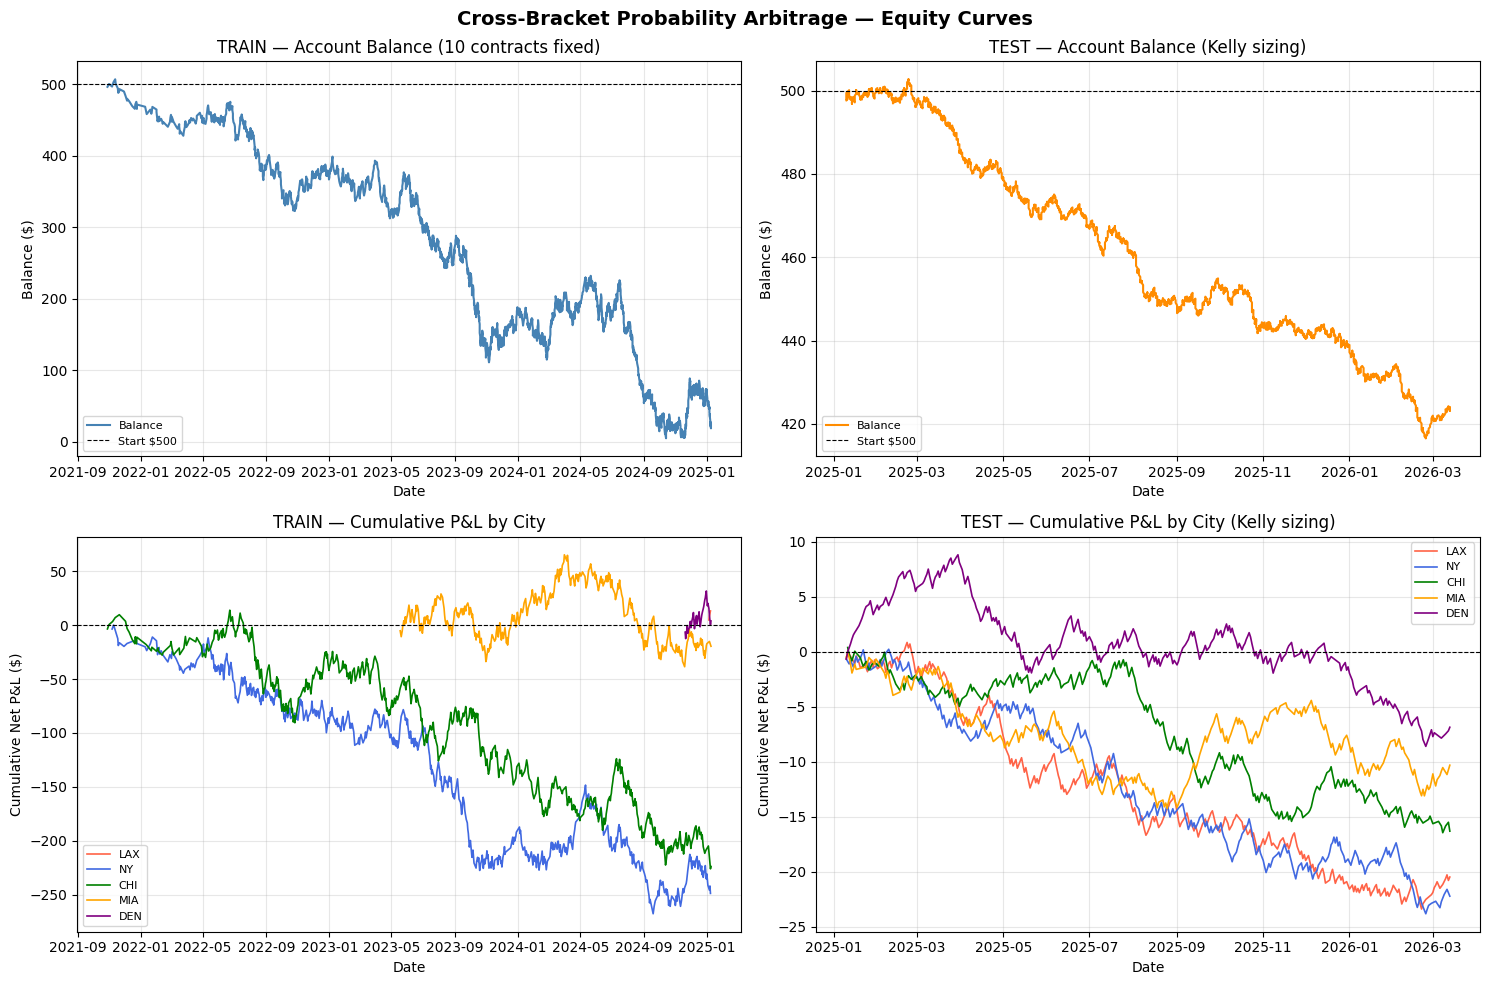

In [8]:
# Cell 9: Equity Curves (4-panel)
#
# Top-left:     Train balance curve
# Top-right:    Test balance curve (Kelly sizing)
# Bottom-left:  Train cumulative P&L by city
# Bottom-right: Test cumulative P&L by city

city_colors = {
    "LAX": "tomato",
    "NY":  "royalblue",
    "CHI": "green",
    "MIA": "orange",
    "DEN": "purple",
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Cross-Bracket Probability Arbitrage — Equity Curves", fontsize=14, fontweight="bold")

train_exec = train_results[train_results["executed"] == True].copy()
test_exec  = test_results[test_results["executed"]  == True].copy()

# ── (0,0) Train: account balance ────────────────────────────────────────────
ax = axes[0, 0]
if not train_exec.empty:
    train_balance = STARTING_BALANCE + train_exec["net_pnl"].cumsum()
    ax.plot(
        pd.to_datetime(train_exec["market_date"]).values,
        train_balance.values,
        color="steelblue", linewidth=1.5, label="Balance",
    )
    ax.axhline(STARTING_BALANCE, color="black", linewidth=0.8, linestyle="--", label=f"Start ${STARTING_BALANCE:.0f}")
ax.set_title("TRAIN — Account Balance (10 contracts fixed)")
ax.set_xlabel("Date")
ax.set_ylabel("Balance ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (0,1) Test: account balance ─────────────────────────────────────────────
ax = axes[0, 1]
if not test_exec.empty:
    test_balance = STARTING_BALANCE + test_exec["net_pnl"].cumsum()
    ax.plot(
        pd.to_datetime(test_exec["market_date"]).values,
        test_balance.values,
        color="darkorange", linewidth=1.5, label="Balance",
    )
    ax.axhline(STARTING_BALANCE, color="black", linewidth=0.8, linestyle="--", label=f"Start ${STARTING_BALANCE:.0f}")
ax.set_title("TEST — Account Balance (Kelly sizing)")
ax.set_xlabel("Date")
ax.set_ylabel("Balance ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (1,0) Train: cumulative P&L by city ─────────────────────────────────────
ax = axes[1, 0]
for city, color in city_colors.items():
    city_df = train_exec[train_exec["city"] == city]
    if city_df.empty:
        continue
    cum = city_df["net_pnl"].cumsum()
    ax.plot(
        pd.to_datetime(city_df["market_date"]).values,
        cum.values, color=color, linewidth=1.2, label=city,
    )
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("TRAIN — Cumulative P&L by City")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Net P&L ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (1,1) Test: cumulative P&L by city ──────────────────────────────────────
ax = axes[1, 1]
for city, color in city_colors.items():
    city_df = test_exec[test_exec["city"] == city]
    if city_df.empty:
        continue
    cum = city_df["net_pnl"].cumsum()
    ax.plot(
        pd.to_datetime(city_df["market_date"]).values,
        cum.values, color=color, linewidth=1.2, label=city,
    )
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("TEST — Cumulative P&L by City (Kelly sizing)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Net P&L ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Cell 10: Slippage Sensitivity (4¢ / 5¢ / 7¢)
#
# Re-run train+test at three slippage levels. Kelly is re-derived from each
# train run. All verbose output suppressed. Prints a comparison table.

_SLIPPAGE_LEVELS = [0.04, 0.05, 0.07]
_sensitivity_rows = []

for _slip in _SLIPPAGE_LEVELS:
    _slip_label = f"{int(round(_slip * 100))}c"

    # ── TRAIN at this slippage ────────────────────────────────────────────────
    _buf = io.StringIO()
    with contextlib.redirect_stdout(_buf):
        _tr = run_backtest(
            signals          = train_signals,
            starting_balance = STARTING_BALANCE,
            fixed_contracts  = TRAIN_CONTRACTS,
            kelly_fraction   = None,
            kelly_win_rate   = None,
            kelly_b          = None,
            slippage         = _slip,
            period_label     = "",
        )

    _tr_exec = _tr[_tr["executed"] == True]
    _tr_n    = len(_tr_exec)
    _tr_wr   = _tr_exec["trade_won"].mean()  if _tr_n > 0 else float("nan")
    _tr_pnl  = _tr_exec["net_pnl"].sum()     if _tr_n > 0 else 0.0
    _tr_roc  = _tr_pnl / STARTING_BALANCE * 100
    _tr_wins = _tr_exec.loc[_tr_exec["net_pnl"] > 0, "net_pnl"]
    _tr_loss = _tr_exec.loc[_tr_exec["net_pnl"] < 0, "net_pnl"]
    _tr_pf   = (
        _tr_wins.sum() / abs(_tr_loss.sum())
        if len(_tr_loss) > 0 and abs(_tr_loss.sum()) > 0
        else float("nan")
    )
    _tr_edge = _tr_exec["net_pnl"].mean() if _tr_n > 0 else float("nan")

    _sensitivity_rows.append({
        "Slippage": _slip_label,
        "Period":   "TRAIN",
        "Trades":   _tr_n,
        "Win Rate": _tr_wr,
        "Net P&L":  _tr_pnl,
        "ROC%":     _tr_roc,
        "Profit Factor":  _tr_pf,
        "Avg Edge/Trade": _tr_edge,
    })

    # ── Derive Kelly from this train run ──────────────────────────────────────
    _s_wins     = _tr_exec[_tr_exec["trade_won"] == True]["net_pnl"]
    _s_losses   = _tr_exec[_tr_exec["trade_won"] == False]["net_pnl"]
    _s_win_rate = float(_tr_exec["trade_won"].mean()) if _tr_n > 0 else 0.5
    _s_avg_win  = float(_s_wins.mean())               if len(_s_wins)   > 0 else 0.0
    _s_avg_loss = float(abs(_s_losses.mean()))         if len(_s_losses) > 0 else 1e-9
    _s_kelly_b  = _s_avg_win / _s_avg_loss

    # ── TEST at this slippage with derived Kelly ───────────────────────────────
    _buf2 = io.StringIO()
    with contextlib.redirect_stdout(_buf2):
        _te = run_backtest(
            signals          = test_signals,
            starting_balance = STARTING_BALANCE,
            fixed_contracts  = None,
            kelly_fraction   = KELLY_FRACTION,
            kelly_win_rate   = _s_win_rate,
            kelly_b          = _s_kelly_b,
            slippage         = _slip,
            period_label     = "",
        )

    _te_exec = _te[_te["executed"] == True]
    _te_n    = len(_te_exec)
    _te_wr   = _te_exec["trade_won"].mean()  if _te_n > 0 else float("nan")
    _te_pnl  = _te_exec["net_pnl"].sum()     if _te_n > 0 else 0.0
    _te_roc  = _te_pnl / STARTING_BALANCE * 100
    _te_wins = _te_exec.loc[_te_exec["net_pnl"] > 0, "net_pnl"]
    _te_loss = _te_exec.loc[_te_exec["net_pnl"] < 0, "net_pnl"]
    _te_pf   = (
        _te_wins.sum() / abs(_te_loss.sum())
        if len(_te_loss) > 0 and abs(_te_loss.sum()) > 0
        else float("nan")
    )
    _te_edge = _te_exec["net_pnl"].mean() if _te_n > 0 else float("nan")

    _sensitivity_rows.append({
        "Slippage": _slip_label,
        "Period":   "TEST",
        "Trades":   _te_n,
        "Win Rate": _te_wr,
        "Net P&L":  _te_pnl,
        "ROC%":     _te_roc,
        "Profit Factor":  _te_pf,
        "Avg Edge/Trade": _te_edge,
    })

# ── Print comparison table ────────────────────────────────────────────────────
_sens_df = pd.DataFrame(_sensitivity_rows)
_disp    = _sens_df.copy()
_disp["Win Rate"]       = _disp["Win Rate"].map("{:.2%}".format)
_disp["Net P&L"]        = _disp["Net P&L"].map("${:.2f}".format)
_disp["ROC%"]           = _disp["ROC%"].map("{:.1f}%".format)
_disp["Profit Factor"]  = _disp["Profit Factor"].map("{:.4f}".format)
_disp["Avg Edge/Trade"] = _disp["Avg Edge/Trade"].map("${:.4f}".format)

print("=" * 95)
print("  SLIPPAGE SENSITIVITY  —  ALL PERIODS")
print("=" * 95)
print(_disp.to_string(index=False))
print()
print("Note: 4c baseline replicates the main run (Kelly re-derived consistently).")
print("      Higher slippage erodes avg edge — watch for sign flip on edge/P&L.")

  SLIPPAGE SENSITIVITY  —  ALL PERIODS
Slippage Period  Trades Win Rate  Net P&L    ROC% Profit Factor Avg Edge/Trade
      4c  TRAIN    1914   56.06% $-475.30  -95.1%        0.8974       $-0.2483
      4c   TEST    1720   56.45%  $-76.13  -15.2%        0.8247       $-0.0443
      5c  TRAIN    1196   54.52% $-501.30 -100.3%        0.8339       $-0.4191
      5c   TEST    1720   56.45%  $-93.33  -18.7%        0.7887       $-0.0543
      7c  TRAIN     846   55.32% $-500.00 -100.0%        0.7712       $-0.5910
      7c   TEST    1720   56.45% $-127.73  -25.5%        0.7203       $-0.0743

Note: 4c baseline replicates the main run (Kelly re-derived consistently).
      Higher slippage erodes avg edge — watch for sign flip on edge/P&L.


In [10]:
# Cell 11: Statistical Significance Tests
#
# Tests run on both TRAIN and TEST periods:
#   [1] Binomial test (one-sided, H1: win_rate > 0.5)
#   [2] One-sample t-test on per-trade net P&L vs 0 (one-sided, H1: mean > 0)
#   [3] Z-test on win rate (one-sided, H1: p > 0.5)
#   [4] Minimum trades needed for 80% power at observed effect size


def run_significance_tests(results_df: pd.DataFrame, period_label: str) -> None:
    """Run binomial, t-test, and z-test on win rate and P&L for a backtest period.

    Parameters
    ----------
    results_df   : DataFrame returned by run_backtest()
    period_label : string label for display
    """
    exec_df = results_df[results_df["executed"] == True].copy()

    if exec_df.empty:
        print(f"{period_label}: no executed trades — skipping significance tests.")
        return

    n_trades    = len(exec_df)
    n_wins      = int(exec_df["trade_won"].sum())
    n_losses    = n_trades - n_wins
    win_rate    = n_wins / n_trades
    net_pnl_arr = exec_df["net_pnl"].values

    sep = "=" * 67
    print(sep)
    print(f"  STATISTICAL SIGNIFICANCE — {period_label}")
    print(sep)
    print(f"  Trades: {n_trades}  |  Wins: {n_wins}  |  Losses: {n_losses}  |  Win Rate: {win_rate:.4f}")
    print()

    # ── [1] Binomial test ────────────────────────────────────────────────────
    binom_result = stats.binomtest(k=n_wins, n=n_trades, p=0.5, alternative="greater")
    binom_pval   = binom_result.pvalue
    binom_sig    = binom_pval < 0.05

    print("  [1] BINOMIAL TEST  (H0: p=0.5, H1: p>0.5, one-sided)")
    print(f"      Observed win rate : {win_rate:.4f}")
    print(f"      n_wins / n_trades  : {n_wins} / {n_trades}")
    print(f"      p-value            : {binom_pval:.6f}")
    verdict_b = "SIGNIFICANT at alpha=0.05" if binom_sig else "NOT significant at alpha=0.05"
    print(f"      Verdict            : {verdict_b}")
    print()

    # ── [2] One-sample t-test ────────────────────────────────────────────────
    t_stat, t_pval = stats.ttest_1samp(net_pnl_arr, 0.0, alternative="greater")
    mean_pnl = net_pnl_arr.mean()
    se_pnl   = net_pnl_arr.std(ddof=1) / math.sqrt(n_trades)
    t_crit   = stats.t.ppf(0.05, df=n_trades - 1)
    ci_low   = mean_pnl + t_crit * se_pnl    # one-sided lower bound
    ttest_sig = t_pval < 0.05

    print("  [2] ONE-SAMPLE T-TEST  (H0: mean_pnl=0, H1: mean_pnl>0, one-sided)")
    print(f"      Mean P&L / trade   : ${mean_pnl:.4f}")
    print(f"      t-statistic        : {t_stat:.4f}")
    print(f"      p-value            : {t_pval:.6f}")
    print(f"      95% CI lower bound : ${ci_low:.4f}  (upper: +inf)")
    verdict_t = "SIGNIFICANT at alpha=0.05" if ttest_sig else "NOT significant at alpha=0.05"
    print(f"      Verdict            : {verdict_t}")
    print()

    # ── [3] Z-test on win rate ───────────────────────────────────────────────
    z_score = (win_rate - 0.5) / math.sqrt(0.25 / n_trades)
    z_pval  = 1.0 - stats.norm.cdf(z_score)
    z_sig   = z_pval < 0.05

    print("  [3] Z-TEST ON WIN RATE  (H0: p=0.5, H1: p>0.5, one-sided)")
    print(f"      Z-score            : {z_score:.4f}")
    print(f"      p-value            : {z_pval:.6f}")
    verdict_z = "SIGNIFICANT at alpha=0.05" if z_sig else "NOT significant at alpha=0.05"
    print(f"      Verdict            : {verdict_z}")
    print()

    # ── [4] Power analysis ───────────────────────────────────────────────────
    delta = win_rate - 0.5
    if delta > 0:
        z_alpha  = stats.norm.ppf(0.95)   # one-sided alpha=0.05
        z_beta   = stats.norm.ppf(0.80)   # 80% power
        n_needed = ((z_alpha + z_beta) ** 2 * 0.25) / (delta ** 2)
        print("  [4] MINIMUM TRADES FOR 80% POWER")
        print(f"      Observed effect (p - 0.5) : {delta:.4f}")
        print(f"      Trades needed (80% power) : {int(math.ceil(n_needed))}")
        print(f"      Trades available          : {n_trades}")
        powered = "Adequately powered" if n_trades >= n_needed else "UNDERPOWERED"
        print(f"      Assessment                : {powered}")
    else:
        print("  [4] Effect size <= 0 — power analysis not meaningful.")
    print()
    print(sep)
    print()


# ── Run on both periods ───────────────────────────────────────────────────────
run_significance_tests(test_results,   "TEST")
run_significance_tests(train_results,  "TRAIN")

  STATISTICAL SIGNIFICANCE — TEST
  Trades: 1720  |  Wins: 971  |  Losses: 749  |  Win Rate: 0.5645

  [1] BINOMIAL TEST  (H0: p=0.5, H1: p>0.5, one-sided)
      Observed win rate : 0.5645
      n_wins / n_trades  : 971 / 1720
      p-value            : 0.000000
      Verdict            : SIGNIFICANT at alpha=0.05

  [2] ONE-SAMPLE T-TEST  (H0: mean_pnl=0, H1: mean_pnl>0, one-sided)
      Mean P&L / trade   : $-0.0443
      t-statistic        : -3.8075
      p-value            : 0.999927
      95% CI lower bound : $-0.0634  (upper: +inf)
      Verdict            : NOT significant at alpha=0.05

  [3] Z-TEST ON WIN RATE  (H0: p=0.5, H1: p>0.5, one-sided)
      Z-score            : 5.3529
      p-value            : 0.000000
      Verdict            : SIGNIFICANT at alpha=0.05

  [4] MINIMUM TRADES FOR 80% POWER
      Observed effect (p - 0.5) : 0.0645
      Trades needed (80% power) : 372
      Trades available          : 1720
      Assessment                : Adequately powered


  STAT

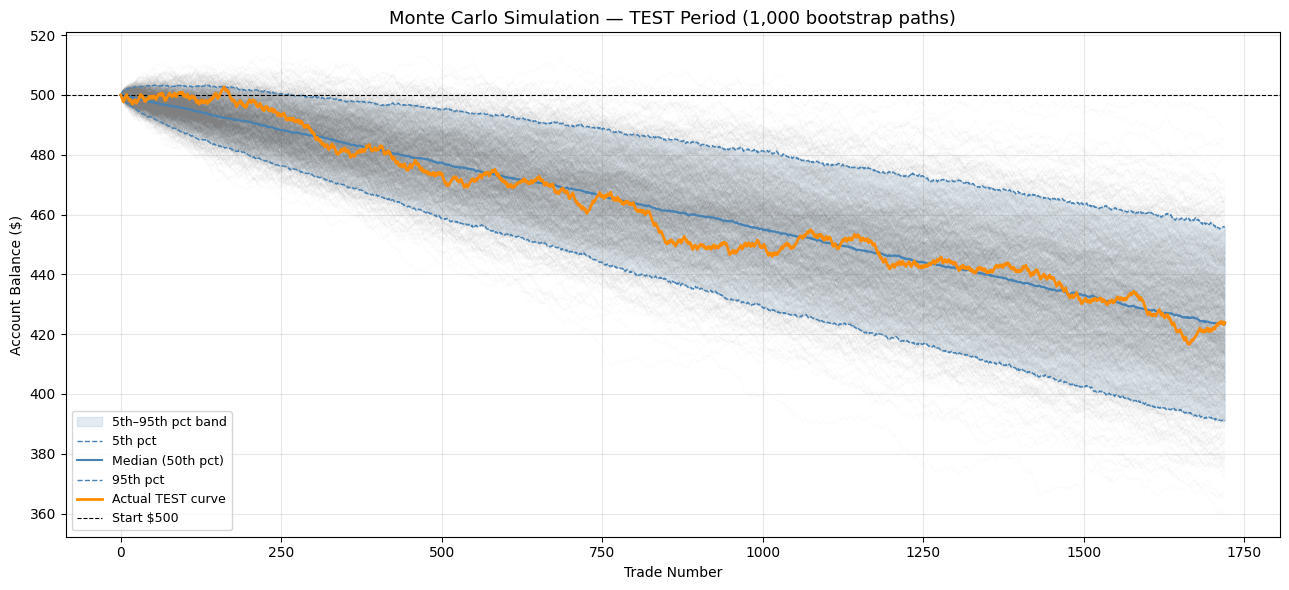


Monte Carlo Summary (1,000 paths, 1720 trades each):
  Ruin rate (final balance = $0) : 0.0%
  Median final balance           : $423.34
  5th percentile final balance   : $391.03
  95th percentile final balance  : $455.93
  Actual final balance           : $423.87


In [11]:
# Cell 12: Monte Carlo Simulation (1,000 paths)
#
# Bootstrap resample the TEST-period per-trade P&L 1,000 times.
# Each path applies a ruin floor (balance cannot go below 0).
# Plot: all paths (gray, alpha=0.05), 5th/50th/95th percentile bands,
#        actual curve, and $500 baseline.

N_SIMS = 1000
rng    = np.random.default_rng(seed=42)

test_exec_for_mc = test_results[test_results["executed"] == True].copy()
test_exec_pnl    = test_exec_for_mc["net_pnl"].values
n_test_trades    = len(test_exec_pnl)

if n_test_trades == 0:
    print("No executed TEST trades — skipping Monte Carlo.")
else:
    # ── Actual equity curve ───────────────────────────────────────────────────
    actual_curve = np.concatenate(
        [[STARTING_BALANCE], STARTING_BALANCE + np.cumsum(test_exec_pnl)]
    )
    actual_curve = np.maximum(actual_curve, 0.0)

    # ── 1,000 bootstrap paths ─────────────────────────────────────────────────
    sim_curves         = np.empty((N_SIMS, n_test_trades + 1))
    sim_final_balances = np.empty(N_SIMS)

    for s in range(N_SIMS):
        sampled  = rng.choice(test_exec_pnl, size=n_test_trades, replace=True)
        curve    = np.empty(n_test_trades + 1)
        curve[0] = STARTING_BALANCE
        ruined   = False
        for i, pnl in enumerate(sampled):
            if ruined:
                curve[i + 1] = 0.0
            else:
                new_bal = curve[i] + pnl
                if new_bal <= 0:
                    new_bal = 0.0
                    ruined  = True
                curve[i + 1] = new_bal
        sim_curves[s]         = curve
        sim_final_balances[s] = curve[-1]

    # ── Percentile bands ──────────────────────────────────────────────────────
    pct_05 = np.percentile(sim_curves, 5,  axis=0)
    pct_50 = np.percentile(sim_curves, 50, axis=0)
    pct_95 = np.percentile(sim_curves, 95, axis=0)
    x_axis = np.arange(n_test_trades + 1)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 6))

    # Gray simulation paths (thin, semi-transparent)
    for s in range(N_SIMS):
        ax.plot(x_axis, sim_curves[s], color="gray", alpha=0.05, linewidth=0.4)

    # Percentile bands
    ax.fill_between(x_axis, pct_05, pct_95, alpha=0.15, color="steelblue", label="5th–95th pct band")
    ax.plot(x_axis, pct_05, color="steelblue", linewidth=1.0, linestyle="--", label="5th pct")
    ax.plot(x_axis, pct_50, color="steelblue", linewidth=1.5, linestyle="-",  label="Median (50th pct)")
    ax.plot(x_axis, pct_95, color="steelblue", linewidth=1.0, linestyle="--", label="95th pct")

    # Actual curve
    ax.plot(x_axis, actual_curve, color="darkorange", linewidth=2.0, zorder=5, label="Actual TEST curve")

    # Baseline
    ax.axhline(STARTING_BALANCE, color="black", linewidth=0.8, linestyle="--", label=f"Start ${STARTING_BALANCE:.0f}")

    ax.set_title(f"Monte Carlo Simulation — TEST Period ({N_SIMS:,} bootstrap paths)", fontsize=13)
    ax.set_xlabel("Trade Number")
    ax.set_ylabel("Account Balance ($)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Summary statistics ────────────────────────────────────────────────────
    pct_ruined   = (sim_final_balances == 0.0).mean() * 100
    med_final    = np.median(sim_final_balances)
    p05_final    = np.percentile(sim_final_balances, 5)
    p95_final    = np.percentile(sim_final_balances, 95)
    actual_final = actual_curve[-1]

    print(f"\nMonte Carlo Summary ({N_SIMS:,} paths, {n_test_trades} trades each):")
    print(f"  Ruin rate (final balance = $0) : {pct_ruined:.1f}%")
    print(f"  Median final balance           : ${med_final:.2f}")
    print(f"  5th percentile final balance   : ${p05_final:.2f}")
    print(f"  95th percentile final balance  : ${p95_final:.2f}")
    print(f"  Actual final balance           : ${actual_final:.2f}")

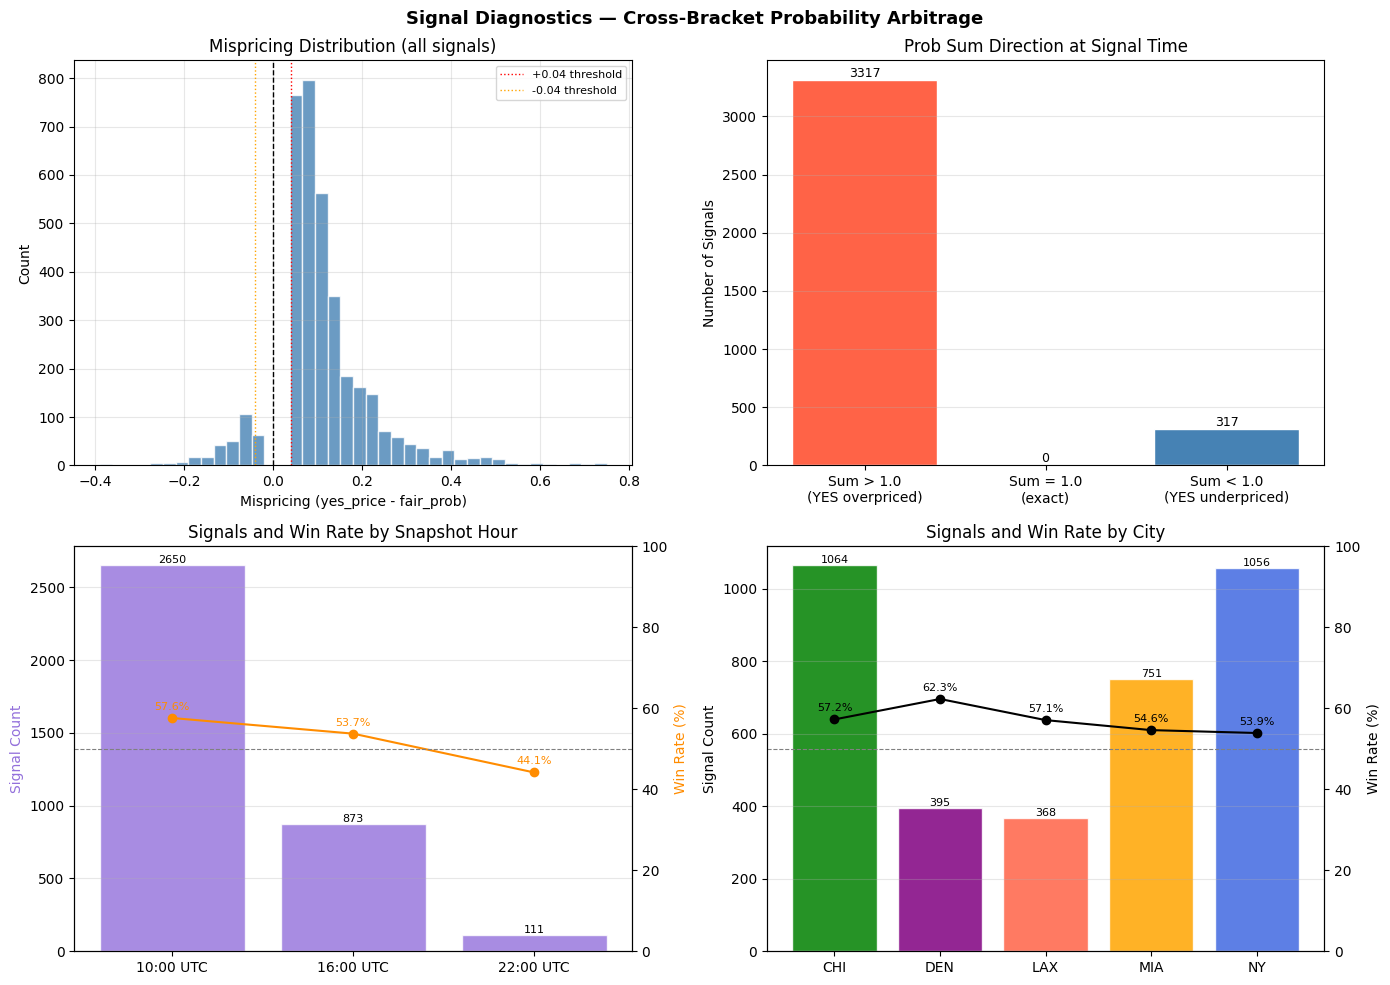


Diagnostics summary:
  Total signals         : 3634
  Prob sum > 1.0        : 3317  (91.3%) — BUY_NO candidates
  Prob sum < 1.0        : 317  (8.7%) — BUY_YES candidates
  BUY_NO signals        : 3317
  BUY_YES signals       : 317
  Mean |mispricing|     : 0.1264
  Max |mispricing|      : 0.7490
  Overall win rate      : 56.25%

By snapshot hour:
 snapshot_hour  count win_rate
            10   2650    57.6%
            16    873    53.7%
            22    111    44.1%

By city:
city  count win_rate
 CHI   1064    57.2%
 DEN    395    62.3%
 LAX    368    57.1%
 MIA    751    54.6%
  NY   1056    53.9%


In [12]:
# Cell 13: Signal Diagnostics
#
# 1. Mispricing distribution histogram for all signals
# 2. How often prob_sum_all > 1.0 vs < 1.0
# 3. By snapshot hour: signal count and win rate
# 4. By city: signal count and win rate

if all_signals_df.empty:
    print("No signals to diagnose.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Signal Diagnostics — Cross-Bracket Probability Arbitrage", fontsize=13, fontweight="bold")

    # ── (0,0) Mispricing distribution histogram ───────────────────────────────
    ax = axes[0, 0]
    mispricings = all_signals_df["mispricing_value"].values
    ax.hist(mispricings, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0,                    color="black",  linewidth=1.0, linestyle="--")
    ax.axvline( MISPRICING_THRESHOLD, color="red",    linewidth=1.0, linestyle=":",
                label=f"+{MISPRICING_THRESHOLD:.2f} threshold")
    ax.axvline(-MISPRICING_THRESHOLD, color="orange", linewidth=1.0, linestyle=":",
                label=f"-{MISPRICING_THRESHOLD:.2f} threshold")
    ax.set_title("Mispricing Distribution (all signals)")
    ax.set_xlabel("Mispricing (yes_price - fair_prob)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── (0,1) prob_sum_all > 1.0 vs < 1.0 ───────────────────────────────────
    ax = axes[0, 1]
    prob_sums = all_signals_df["prob_sum_all"].values
    over_sum  = (prob_sums > 1.0).sum()
    under_sum = (prob_sums < 1.0).sum()
    exact_sum = (prob_sums == 1.0).sum()
    ax.bar(["Sum > 1.0\n(YES overpriced)", "Sum = 1.0\n(exact)", "Sum < 1.0\n(YES underpriced)"],
           [over_sum, exact_sum, under_sum],
           color=["tomato", "gray", "steelblue"], edgecolor="white")
    ax.set_title("Prob Sum Direction at Signal Time")
    ax.set_ylabel("Number of Signals")
    for bar_i, val in enumerate([over_sum, exact_sum, under_sum]):
        ax.text(bar_i, val + 0.5, str(val), ha="center", va="bottom", fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

    # ── (1,0) By snapshot hour ────────────────────────────────────────────────
    ax = axes[1, 0]
    hour_group = all_signals_df.groupby("snapshot_hour").agg(
        count   = ("trade_won", "count"),
        win_rate = ("trade_won", "mean"),
    ).reset_index()

    x_pos   = np.arange(len(hour_group))
    bars    = ax.bar(x_pos, hour_group["count"], color="mediumpurple", edgecolor="white", alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{int(h):02d}:00 UTC" for h in hour_group["snapshot_hour"]])
    ax.set_title("Signals and Win Rate by Snapshot Hour")
    ax.set_ylabel("Signal Count", color="mediumpurple")

    ax2 = ax.twinx()
    ax2.plot(x_pos, hour_group["win_rate"] * 100, color="darkorange",
             marker="o", linewidth=1.5, markersize=6, label="Win Rate %")
    ax2.axhline(50, color="gray", linewidth=0.8, linestyle="--")
    ax2.set_ylabel("Win Rate (%)", color="darkorange")
    ax2.set_ylim(0, 100)

    for bar_i, (cnt, wr) in enumerate(zip(hour_group["count"], hour_group["win_rate"])):
        ax.text(bar_i, cnt + 0.3, f"{cnt}", ha="center", va="bottom", fontsize=8)
        ax2.text(bar_i, wr * 100 + 1.5, f"{wr:.1%}", ha="center", va="bottom",
                 fontsize=8, color="darkorange")
    ax.grid(True, alpha=0.3, axis="y")

    # ── (1,1) By city ─────────────────────────────────────────────────────────
    ax = axes[1, 1]
    city_group = all_signals_df.groupby("city").agg(
        count    = ("trade_won", "count"),
        win_rate = ("trade_won", "mean"),
    ).reset_index()

    colors_list = [city_colors.get(c, "gray") for c in city_group["city"]]
    x_pos2 = np.arange(len(city_group))
    ax.bar(x_pos2, city_group["count"], color=colors_list, edgecolor="white", alpha=0.85)
    ax.set_xticks(x_pos2)
    ax.set_xticklabels(city_group["city"])
    ax.set_title("Signals and Win Rate by City")
    ax.set_ylabel("Signal Count")

    ax3 = ax.twinx()
    ax3.plot(x_pos2, city_group["win_rate"] * 100, color="black",
             marker="o", linewidth=1.5, markersize=6)
    ax3.axhline(50, color="gray", linewidth=0.8, linestyle="--")
    ax3.set_ylabel("Win Rate (%)")
    ax3.set_ylim(0, 100)

    for i, (cnt, wr) in enumerate(zip(city_group["count"], city_group["win_rate"])):
        ax.text(i, cnt + 0.3, f"{cnt}", ha="center", va="bottom", fontsize=8)
        ax3.text(i, wr * 100 + 1.5, f"{wr:.1%}", ha="center", va="bottom", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    # ── Text summary ──────────────────────────────────────────────────────────
    print(f"\nDiagnostics summary:")
    print(f"  Total signals         : {len(all_signals_df)}")
    print(f"  Prob sum > 1.0        : {over_sum}  ({over_sum/len(all_signals_df):.1%}) — BUY_NO candidates")
    print(f"  Prob sum < 1.0        : {under_sum}  ({under_sum/len(all_signals_df):.1%}) — BUY_YES candidates")
    print(f"  BUY_NO signals        : {(all_signals_df['side'] == 'BUY_NO').sum()}")
    print(f"  BUY_YES signals       : {(all_signals_df['side'] == 'BUY_YES').sum()}")
    print(f"  Mean |mispricing|     : {all_signals_df['mispricing_value'].abs().mean():.4f}")
    print(f"  Max |mispricing|      : {all_signals_df['mispricing_value'].abs().max():.4f}")
    print(f"  Overall win rate      : {all_signals_df['trade_won'].mean():.2%}")
    print()
    print("By snapshot hour:")
    print(hour_group.assign(win_rate=hour_group["win_rate"].map("{:.1%}".format)).to_string(index=False))
    print()
    print("By city:")
    print(city_group.assign(win_rate=city_group["win_rate"].map("{:.1%}".format)).to_string(index=False))

In [13]:
# Cell 14: Save Trade Logs
#
# Save train and test trade records to backtest_data/ for further analysis.

display_cols = [
    "market_date", "city", "ticker",
    "side", "yes_price", "no_price_raw", "entry_price_raw",
    "fair_prob", "mispricing",
    "num_contracts", "executed", "skip_reason",
    "actual_entry", "entry_fee",
    "settlement_value", "trade_won",
    "gross_pnl", "net_pnl",
    "balance_before", "balance_after",
]

train_cols = [c for c in display_cols if c in train_results.columns]
test_cols  = [c for c in display_cols if c in test_results.columns]

# ── Save train log ────────────────────────────────────────────────────────────
train_out = DATA_DIR / "cross_bracket_arb_train_trades.csv"
train_results[train_cols].to_csv(train_out, index=False)
print(f"Train trade log saved : {train_out}  ({len(train_results)} rows)")

# ── Save test log ─────────────────────────────────────────────────────────────
test_out = DATA_DIR / "cross_bracket_arb_test_trades.csv"
test_results[test_cols].to_csv(test_out, index=False)
print(f"Test trade log saved  : {test_out}  ({len(test_results)} rows)")

# ── Quick display of first 30 executed TEST trades ────────────────────────────
print(f"\nFirst 30 executed TEST trades:")
test_exec_display = test_results[test_results["executed"] == True][test_cols].head(30)
print(test_exec_display.to_string(index=False))

Train trade log saved : C:\Users\ethan\Downloads\Kalshitrading\LIVE\backtest_data\cross_bracket_arb_train_trades.csv  (1914 rows)
Test trade log saved  : C:\Users\ethan\Downloads\Kalshitrading\LIVE\backtest_data\cross_bracket_arb_test_trades.csv  (1720 rows)

First 30 executed TEST trades:
market_date city                  ticker    side  yes_price  no_price_raw  entry_price_raw  fair_prob  mispricing  num_contracts  executed skip_reason  actual_entry  entry_fee  settlement_value  trade_won  gross_pnl  net_pnl  balance_before  balance_after
 2025-01-10   NY  KXHIGHNY-25JAN10-B39.5  BUY_NO       0.42          0.58             0.58      0.260       0.160              1      True        None          0.62       0.02               1.0      False      -0.62    -0.64          500.00         499.36
 2025-01-10  LAX KXHIGHLAX-25JAN10-B69.5  BUY_NO       0.45          0.55             0.55      0.120       0.330              1      True        None          0.59       0.02               1.0    